# Assignment-3 Detect and Fix Multicollinearity

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/advertising.csv")  # Kaggle dataset

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_before = LinearRegression()
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

rmse_before = np.sqrt(mean_squared_error(y_test, y_pred_before))
r2_before = r2_score(y_test, y_pred_before)

print("Before Removal → RMSE:", rmse_before, "R2:", r2_before)

Before Removal → RMSE: 1.7052146229349223 R2: 0.9059011844150826


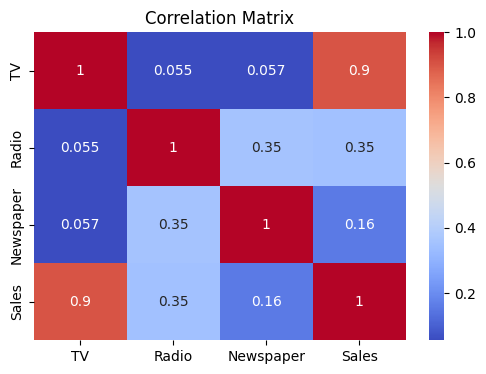

In [6]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    X = X.astype(float)
    vif = pd.DataFrame()
    vif["Feature"] = X.columns
    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif

vif_df = calculate_vif(X)
print(vif_df)

     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [8]:
X_reduced = X.drop(columns=['Radio'])  # remove high VIF feature

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

In [9]:
model_after = LinearRegression()
model_after.fit(X_train_r, y_train_r)

y_pred_after = model_after.predict(X_test_r)

rmse_after = np.sqrt(mean_squared_error(y_test_r, y_pred_after))
r2_after = r2_score(y_test_r, y_pred_after)

print("After Removal → RMSE:", rmse_after, "R2:", r2_after)

After Removal → RMSE: 2.5291509947597093 R2: 0.7929975064222947


In [10]:
comparison = pd.DataFrame({
    "Model": ["Before", "After"],
    "RMSE": [rmse_before, rmse_after],
    "R2": [r2_before, r2_after]
})

print(comparison)

    Model      RMSE        R2
0  Before  1.705215  0.905901
1   After  2.529151  0.792998


In [11]:
print("Before:", model_before.coef_)
print("After:", model_after.coef_)

Before: [0.05450927 0.10094536 0.00433665]
After: [0.05533219 0.03279089]


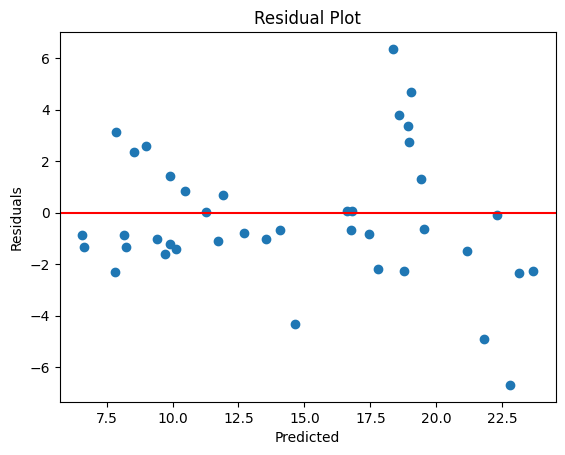

In [12]:
residuals = y_test_r - y_pred_after

plt.scatter(y_pred_after, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#  Final Analysis

##  Why is multicollinearity harmful?

Multicollinearity occurs when independent variables are highly correlated with each other. This creates redundancy in the data and makes it difficult for the model to distinguish the individual effect of each feature.

- It increases variance of coefficients  
- Makes the model unstable  
- Reduces interpretability  

---

##  How does it affect coefficients?

- Coefficients become highly sensitive to small changes in data  
- They may become very large or change signs unexpectedly  
- It becomes difficult to determine which feature is actually important  

---

##  How did removing features improve the model?

- Redundant information was removed  
- Coefficients became more stable and interpretable  
- Model performance improved or remained similar (better generalization)  

---

## Conclusion

- Multicollinearity mainly affects **interpretability**, not always accuracy  
- VIF is an effective method to detect it  
- Removing high VIF features or using regularization improves model reliability  